In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # or RobustScaler – pick one
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# import the data
bos =pd.read_csv("/workspaces/Machine-Learining-Models/day_003_ridge_regression/Boston copy.csv")
bos.head(10)

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [3]:
# start by xploring the datatypes and other data info
bos.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


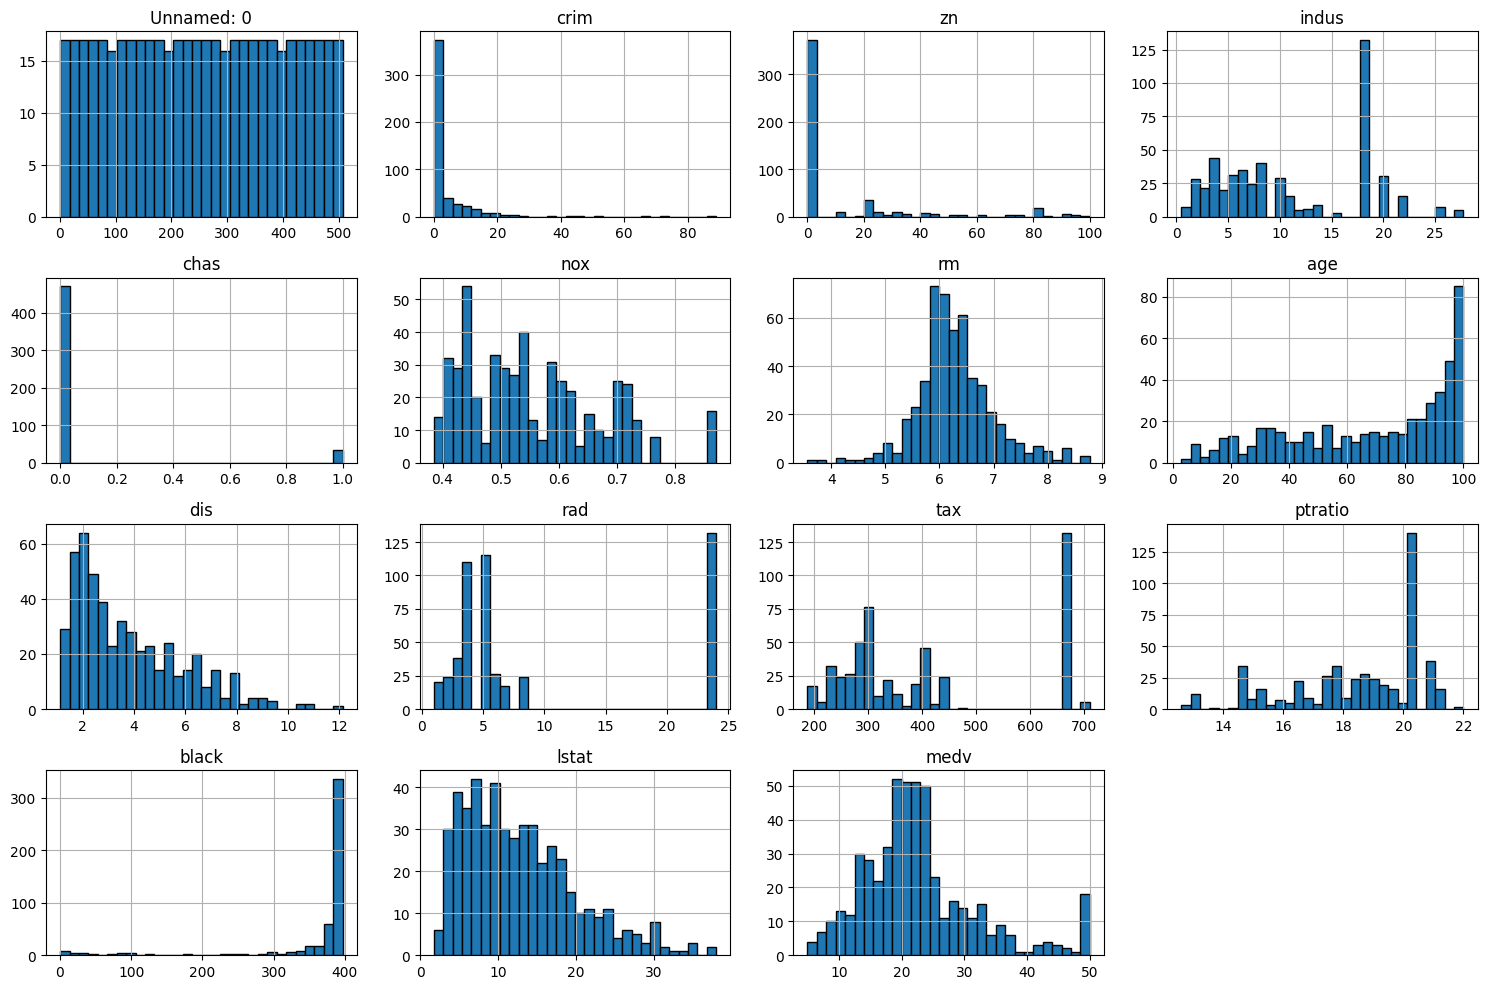

In [4]:
bos.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

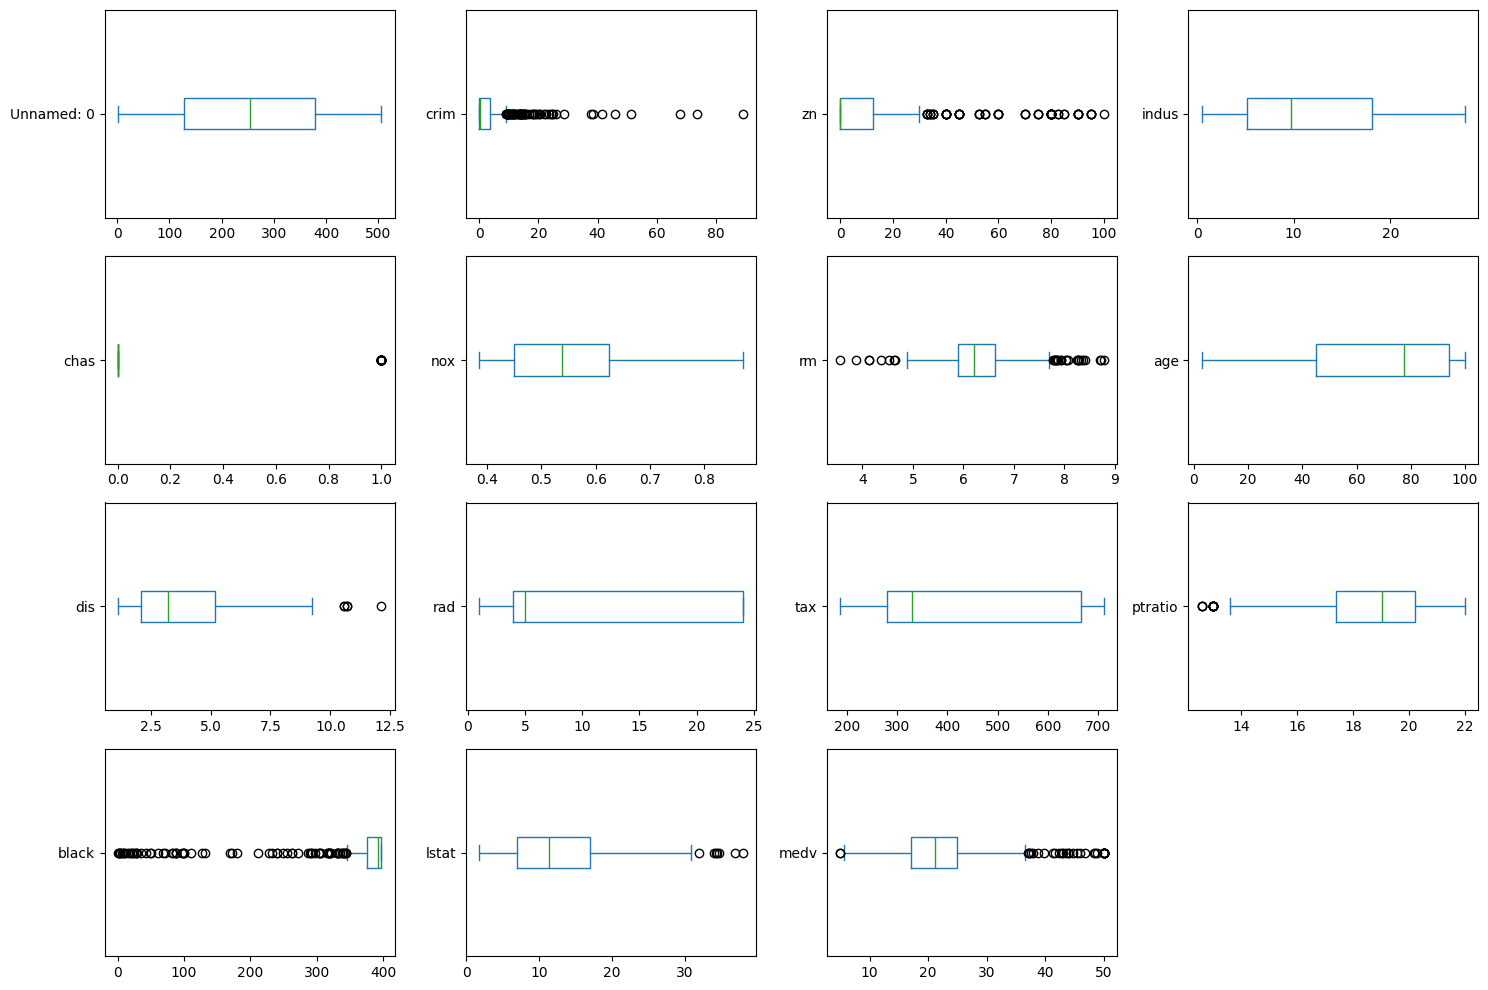

In [5]:

# Check for outliers


bos.plot(kind='box', subplots=True, layout=(4, 4), figsize=(15, 10), sharex=False, sharey=False, vert = False)
plt.tight_layout()
plt.show()

In [6]:
def get_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create a boolean mask of outliers
    outliers_mask = (df < lower_bound) | (df > upper_bound)
    
    # Return count of outliers per column
    return outliers_mask.sum()

# Execute for your dataset
outlier_counts = get_outliers(bos)
print("Outliers per column:")
print(outlier_counts)

Outliers per column:
Unnamed: 0     0
crim          66
zn            68
indus          0
chas          35
nox            0
rm            30
age            0
dis            5
rad            0
tax            0
ptratio       15
black         77
lstat          7
medv          40
dtype: int64


<Axes: >

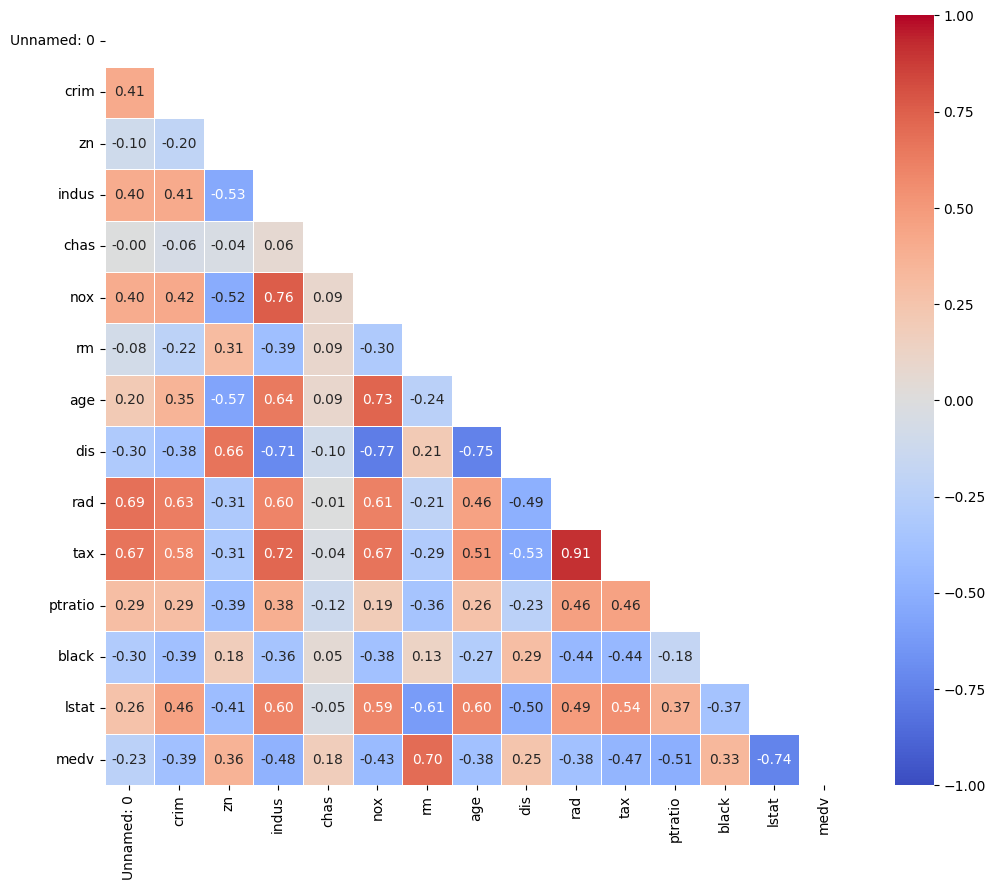

In [7]:
# Calculate the correlation matrix
corr_matrix = bos.corr()

# Create a mask to hide the redundant upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(12, 10))


# annot=True shows the correlation values
# cmap='coolwarm' uses blue for negative and red for positive correlations
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
            fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

**Wrangle function**

In [8]:
def wrangle(filepath):
    # Load data
    df = pd.read_csv(filepath)
    
    # Drop unnecessary columns
    df.drop(columns=['Unnamed: 0', 'chas'], inplace=True)
    
    return df

df = wrangle("/workspaces/Machine-Learining-Models/day_003_ridge_regression/Boston.csv")
df.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**SPLIT**

In [9]:
X= df.drop(columns = ['medv'])
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Y set size: {y_train.shape}")
print(f"yTest set size: {y_test.shape}")

Training set size: (404, 12)
Test set size: (102, 12)
Y set size: (404,)
yTest set size: (102,)


**MODEL**

In [16]:
# Baseline
y_baseline_pred = [y_train.mean()] * len(y_train)

baseline_mae = mean_absolute_error(y_train, y_baseline_pred)
print(f"Baseline MAE (predicting mean): {baseline_mae:.4f}")

Baseline MAE (predicting mean): 6.8093


In [10]:
def ridge_model(X_train, y_train, X_test, y_test):
    alphas = np.logspace(-3, 3, 100) # Tests 100 values between 0.001 and 1000

    # RidgeCV finds the best alpha using cross-validation
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas, scoring='neg_root_mean_squared_error'))
    ])
    
    #  Fit
    pipeline.fit(X_train, y_train)
    
    #Extract the best alpha 
    best_alpha = pipeline.named_steps['ridge'].alpha_

    print(f"Best Alpha: {best_alpha:.4f}")
    return pipeline, best_alpha

# Now call the function
model, best_a = ridge_model(X_train, y_train, X_test, y_test)

Best Alpha: 6.5793


In [14]:
y_pred = model.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


MAE  : 3.2185
RMSE : 4.9776
R²   : 0.6621


In [30]:
ridge = model.named_steps['ridge']
coefs = ridge.coef_
intercept = ridge.intercept_
feature_names = X_train.columns

coefs_series = pd.Series( coefs, index = feature_names)
coefs_series

crim      -0.997698
zn         0.628193
indus      0.263080
nox       -1.716375
rm         3.224549
age       -0.149027
dis       -2.892001
rad        1.984447
tax       -1.557108
ptratio   -2.044176
black      1.167151
lstat     -3.645444
dtype: float64

In [ ]:

best_a['best_alpha']


**RESIDUALS**

In [23]:
from IPython.display import display

# Show first 20 rows with highlighting
styled = comparison_df.head(20).style.format({
    'y_test': '{:.2f}',
    'y_pred': '{:.2f}',
    'residual': '{:.2f}'
}).background_gradient(cmap='coolwarm', subset=['residual'])
display(styled)

,y_test,y_pred,residual
173,23.60,29.08,-5.48
274,32.40,33.16,-0.76
491,13.60,15.51,-1.91
72,22.80,25.02,-2.22
452,16.10,19.15,-3.05
76,20.00,23.33,-3.33
316,17.80,17.88,-0.08
140,14.00,14.70,-0.70
471,19.60,23.00,-3.40
500,16.80,20.90,-4.10


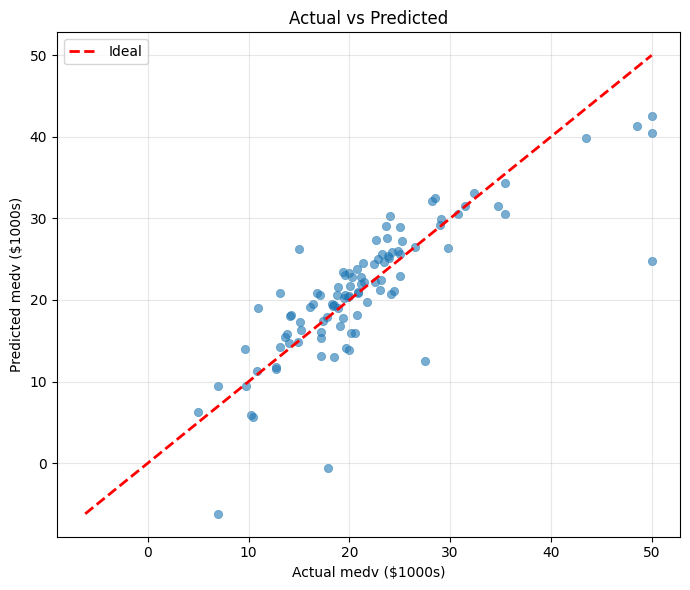

In [26]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, edgecolor=None)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
plt.xlabel("Actual medv ($1000s)")
plt.ylabel("Predicted medv ($1000s)")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

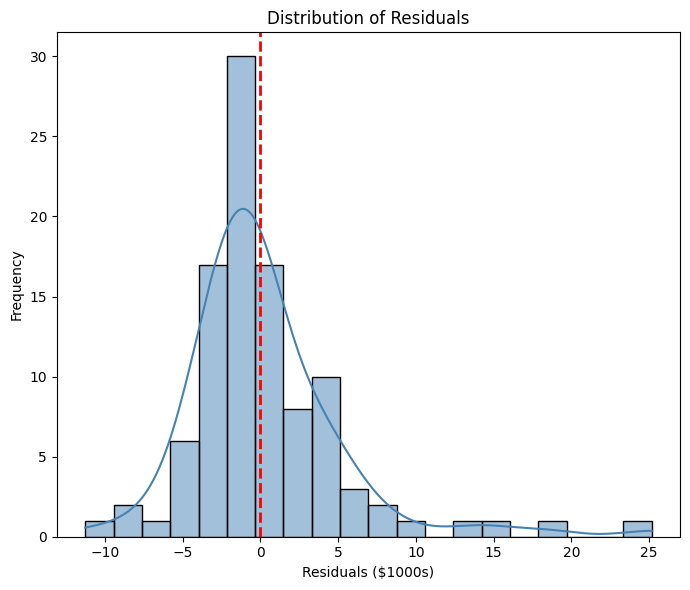

In [27]:
plt.figure(figsize=(7, 6))
sns.histplot(residuals, kde=True, color='steelblue', bins=20)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.xlabel("Residuals ($1000s)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

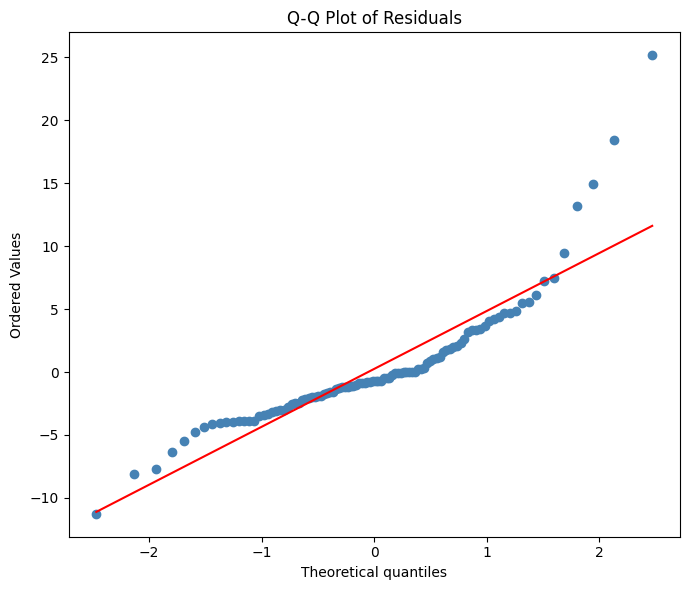

In [29]:
from scipy import stats
plt.figure(figsize=(7, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.gca().get_lines()[0].set_color('steelblue')   # data points
plt.gca().get_lines()[1].set_color('red')         # reference line
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()